In [40]:
"""
Poglądowa wizualizacja rozmieszczenia elektrod SEEG na podstawie pliku XML
w formacie:
 
<Electrodes ... ViewType="PatientHead" ...>
    <Electrode>
        <Label>RD1</Label>
        <ChannelType>1</ChannelType>
        <XCoordinate>0.07143</XCoordinate>
        <YCoordinate>0.23974</YCoordinate>
        <SizeFactor>0.50000</SizeFactor>
        <GroupId>2</GroupId>
    </Electrode>
    ...
</Electrodes>
 
UWAGA: to jest schemat 2D "widoku z góry na głowę" (ViewType="PatientHead"),
używany przez oprogramowanie kliniczne do organizacji kanałów — NIE jest to
rzeczywista rekonstrukcja 3D pozycji elektrod w mózgu. X/Y to współrzędne
znormalizowane [0,1] na płaskim schemacie głowy. Nazwa elektrody (shaft) to
prefiks literowy w Label (np. "RD", "RFO", "LTM"), a końcowa liczba to numer
kolejnego kontaktu wzdłuż tej elektrody.
 
Wymagane biblioteki:
    pip install matplotlib pandas
"""

'\nPoglądowa wizualizacja rozmieszczenia elektrod SEEG na podstawie pliku XML\nw formacie:\n\n<Electrodes ... ViewType="PatientHead" ...>\n    <Electrode>\n        <Label>RD1</Label>\n        <ChannelType>1</ChannelType>\n        <XCoordinate>0.07143</XCoordinate>\n        <YCoordinate>0.23974</YCoordinate>\n        <SizeFactor>0.50000</SizeFactor>\n        <GroupId>2</GroupId>\n    </Electrode>\n    ...\n</Electrodes>\n\nUWAGA: to jest schemat 2D "widoku z góry na głowę" (ViewType="PatientHead"),\nużywany przez oprogramowanie kliniczne do organizacji kanałów — NIE jest to\nrzeczywista rekonstrukcja 3D pozycji elektrod w mózgu. X/Y to współrzędne\nznormalizowane [0,1] na płaskim schemacie głowy. Nazwa elektrody (shaft) to\nprefiks literowy w Label (np. "RD", "RFO", "LTM"), a końcowa liczba to numer\nkolejnego kontaktu wzdłuż tej elektrody.\n\nWymagane biblioteki:\n    pip install matplotlib pandas\n'

In [41]:
import re
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
 
XML_PATH = ("/Users/alicjakawecka/Desktop/CZD_sampleData/CZD_sampleData/"
    "2023-07-26{6591E658-D0E0-49FE-BDE4-FC101EACF45D}.eeg/"
    "ElectrodePlacements/SEEG Hanna.xml")


In [42]:
# ---------------------------------------------------------------------------
# 1. PARSOWANIE
# ---------------------------------------------------------------------------
def parse_seeg_xml(path: str) -> pd.DataFrame:
    tree = ET.parse(path)
    root = tree.getroot()
 
    records = []
    for order, el in enumerate(root.findall("Electrode")):
        label = el.find("Label").text
        x = float(el.find("XCoordinate").text)
        y = float(el.find("YCoordinate").text)
        channel_type = el.find("ChannelType").text
        group_id = el.find("GroupId").text
 
        # prefiks literowy = nazwa elektrody (shaft), cyfry na końcu = kontakt
        m = re.match(r"^([A-Za-z]+)(\d+)$", label)
        shaft = m.group(1) if m else label
        contact_num = int(m.group(2)) if m else 0
 
        records.append(
            {
                "label": label,
                "shaft": shaft,
                "contact": contact_num,
                "x": x,
                "y": y,
                "channel_type": channel_type,
                "group_id": group_id,
                "order": order,
            }
        )
 
    return pd.DataFrame(records)
 

In [43]:
# ---------------------------------------------------------------------------
# 2. TŁO — uproszczony schemat głowy widzianej z góry
# ---------------------------------------------------------------------------
def draw_head_outline(ax, cx=0.5, cy=0.48, rx=0.58, ry=0.42):
    """Rysuje owal głowy + nos + uszy jako punkt odniesienia (poglądowo)."""
    head = mpatches.Ellipse(
        (cx, cy), 2 * rx, 2 * ry, fill=True, facecolor="#f5f0eb",
        edgecolor="black", linewidth=1.5, zorder=0,
    )
    ax.add_patch(head)
 
    # nos (mały trójkąt u góry owalu = strona przednia głowy)
    nose_y = cy - ry
    ax.plot(
        [cx - 0.02, cx, cx + 0.02],
        [nose_y, nose_y - 0.03, nose_y],
        color="black", linewidth=1.2, zorder=1,
    )
 
    # uszy (małe półokręgi po bokach)
    for side in (-1, 1):
        ear = mpatches.Ellipse(
            (cx + side * (rx + 0.01), cy), 0.03, 0.08,
            facecolor="#f5f0eb", edgecolor="black", linewidth=1.0, zorder=1,
        )
        ax.add_patch(ear)
 
    ax.text(cx, cy - ry - 0.06, "PRZÓD", ha="center", fontsize=8, color="grey")
    ax.text(cx, cy + ry + 0.06, "TYŁ", ha="center", fontsize=8, color="grey")
    ax.text(cx - rx - 0.07, cy, "L", ha="center", va="center", fontsize=9, color="grey")
    ax.text(cx + rx + 0.07, cy, "P", ha="center", va="center", fontsize=9, color="grey")
 
 

In [44]:
# ---------------------------------------------------------------------------
# 3. RYSOWANIE ELEKTROD
# ---------------------------------------------------------------------------
def plot_seeg(df: pd.DataFrame, save_path="seeg_poglądowy.png"):
    fig, ax = plt.subplots(figsize=(11, 9))
 
    draw_head_outline(ax)
 
    shafts = df["shaft"].unique()
    cmap = plt.colormaps["tab20"].resampled(len(shafts))
 
    for i, shaft in enumerate(shafts):
        sub = df[df["shaft"] == shaft].sort_values(
            "contact" if (df[df["shaft"] == shaft]["contact"] > 0).all() else "order"
        )
        color = cmap(i)
 
        ax.plot(sub["x"], sub["y"], color=color, linewidth=1.8, alpha=0.8, zorder=2)
        ax.scatter(
            sub["x"], sub["y"], color=color, s=55, edgecolor="black",
            linewidth=0.5, zorder=3,
        )
 
        first = sub.iloc[0]
        last = sub.iloc[-1]
        # etykieta elektrody przy pierwszym kontakcie, lekko przesunięta
        ax.annotate(
            shaft,
            xy=(first["x"], first["y"]),
            xytext=(first["x"] - 0.015, first["y"] - 0.02),
            fontsize=9, fontweight="bold", color=color, zorder=4,
        )
 
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(1.05, -0.05)  # odwrócona oś Y (współrzędne obrazu: góra=0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(
        "Poglądowe rozmieszczenie elektrod SEEG (schemat 2D, widok od góry)",
        fontsize=13,
    )
 
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    print(f"Zapisano obraz: {save_path}")
    plt.show()
 

Wczytano 116 kontaktów, 12 elektrod:
['LFO', 'LPX', 'LTM', 'LTS', 'RD', 'RDM', 'RFO', 'RIA', 'RIP', 'RL', 'RM', 'RTS']
Zapisano obraz: seeg_poglądowy.png


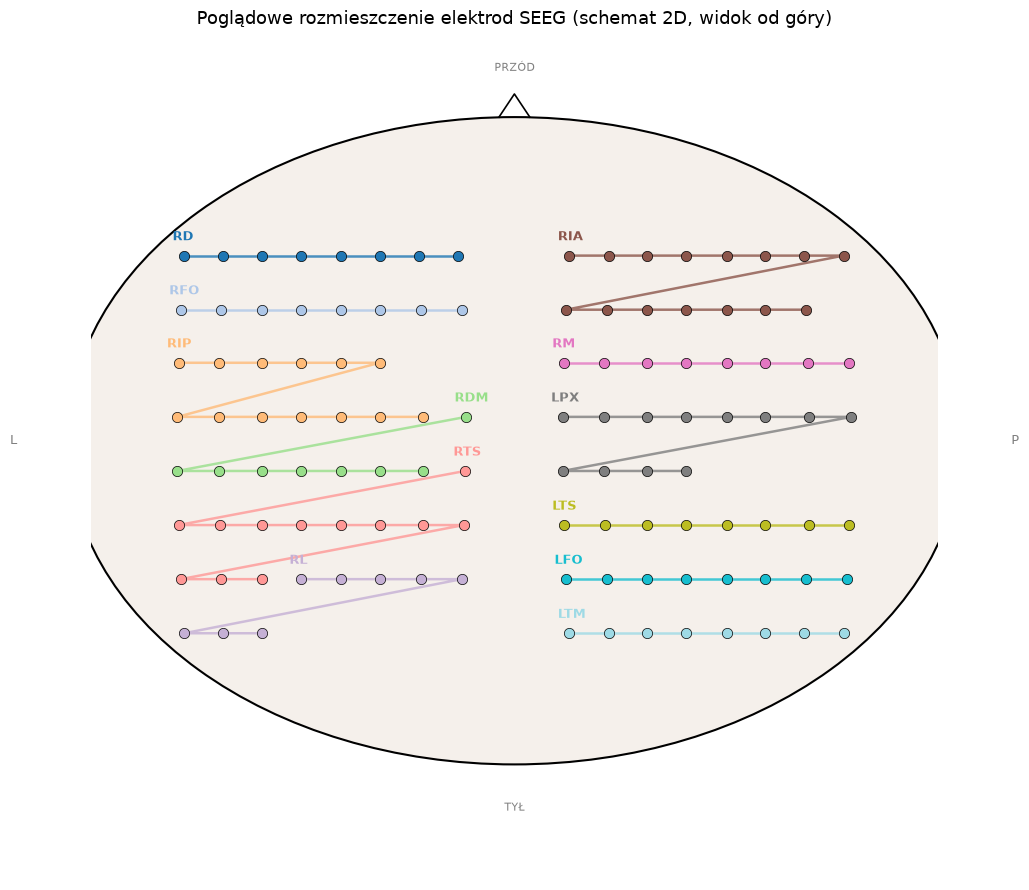

In [45]:
# ---------------------------------------------------------------------------
# URUCHOMIENIE
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    df = parse_seeg_xml(XML_PATH)
    print(f"Wczytano {len(df)} kontaktów, {df['shaft'].nunique()} elektrod:")
    print(sorted(df["shaft"].unique()))
    plot_seeg(df)